# Satellite–Central Cross-Correlation
Compute the cross-correlation $\xi_{\mathrm{sat,cen}}(r)$ between satellite and central galaxies from GALFORM galaxies.hdf5 outputs.

## Import Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import DEFAULT_RBINS, get_snapshot_redshift
from galform_analysis.analysis.correlation import satellite_central_cross_correlation

project_root = Path.cwd().resolve().parents[1]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

base_dir = Path('/cosma5/data/durham/dc-hick2/Tau0_Investigation/Galform_Out_Default/L800/lc16.newmg')
zero_dir = Path('/cosma5/data/durham/dc-hick2/Tau0_Investigation/Galform_Out_0tau0/L800/lc16.newmg')
inf_dir = Path('/cosma5/data/durham/dc-hick2/Tau0_Investigation/Galform_Out_1e6tau0/L800/lc16.newmg')

## Cross-correlation for a single redshift and subvolume

In [4]:
example_snapshot = 'iz207'
example_ivol = 1
satellite_stellar_mass_min = 1e9  # Msun/h
central_stellar_mass_min = 1e9
host_halo_mass_min = 1e9

cross = satellite_central_cross_correlation(
    base_dir / example_snapshot,
    example_ivol,
    rbins=DEFAULT_RBINS,
    nthreads=4,
    satellite_stellar_mass_min=satellite_stellar_mass_min,
    central_stellar_mass_min=central_stellar_mass_min,
    host_halo_mass_min=host_halo_mass_min,
)
cross_zero = satellite_central_cross_correlation(
    zero_dir / example_snapshot,
    example_ivol,
    rbins=DEFAULT_RBINS,
    nthreads=4,
    satellite_stellar_mass_min=satellite_stellar_mass_min,
    central_stellar_mass_min=central_stellar_mass_min,
    host_halo_mass_min=host_halo_mass_min,
)
# cross_inf = satellite_central_cross_correlation(
#     inf_dir / example_snapshot,
#     example_ivol,
#     rbins=DEFAULT_RBINS,
#     nthreads=4,
#     satellite_stellar_mass_min=satellite_stellar_mass_min,
#     central_stellar_mass_min=central_stellar_mass_min,
#     host_halo_mass_min=host_halo_mass_min,
# )

z_val = get_snapshot_redshift(example_snapshot)

print(
    f"Loaded cross-correlation for {cross.attrs['iz']} (z={z_val}), ",
    f"\nbase case ivol={cross.attrs['ivol']}; N_sat={cross.attrs['n_sat']}, N_cen={cross.attrs['n_cen']}.",
    f"\nzero tau0 ivol={cross_zero.attrs['ivol']}; N_sat={cross_zero.attrs['n_sat']}, N_cen={cross_zero.attrs['n_cen']}.",
    #f"infinite tau0 ivol={cross_inf.attrs['ivol']}; N_sat={cross_inf.attrs['n_sat']}, N_cen={cross_inf.attrs['n_cen']}.",
)

Loaded cross-correlation for iz207 (z=0.495942),  
base case ivol=1; N_sat=1938, N_cen=4054. 
zero tau0 ivol=1; N_sat=1423, N_cen=3940.


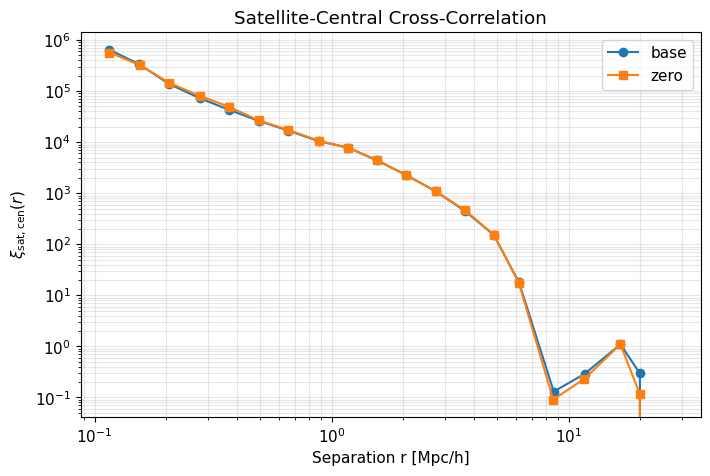

In [5]:
#base
r_base = cross['r'].values
xi_base = cross['xi'].values
valid_base = np.isfinite(xi_base) & (xi_base > -1)

#zero
r_zero = cross_zero['r'].values
xi_zero = cross_zero['xi'].values
valid_zero = np.isfinite(xi_zero) & (xi_zero > -1)

#inf


fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(r_base[valid_base], xi_base[valid_base], 'o-', label='base')
ax.loglog(r_zero[valid_zero], xi_zero[valid_zero], 's-', label='zero')
ax.set_xlabel('Separation r [Mpc/h]')
ax.set_ylabel(r'$\xi_{\mathrm{sat,cen}}(r)$')
ax.set_title('Satellite-Central Cross-Correlation')
ax.legend()
plt.show()

## Cross-correlation across multiple redshifts

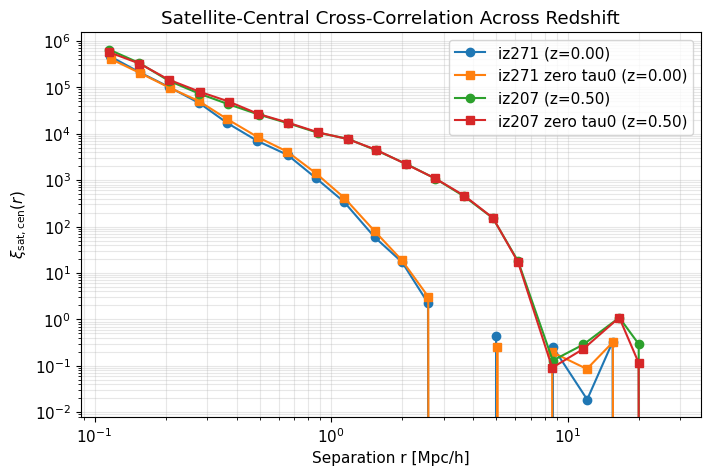

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

redshifts = ['iz271', 'iz207']

for snapshot in redshifts:
    z_val = get_snapshot_redshift(snapshot)
    z_label = f"{z_val:.2f}" if z_val is not None else "n/a"

    res_base = satellite_central_cross_correlation(
        base_dir / snapshot,
        example_ivol,
        rbins=DEFAULT_RBINS,
        nthreads=4,
        satellite_stellar_mass_min=satellite_stellar_mass_min,
        central_stellar_mass_min=central_stellar_mass_min,
        host_halo_mass_min=host_halo_mass_min,
    )
    res_zero = satellite_central_cross_correlation(
        zero_dir / snapshot,
        example_ivol,
        rbins=DEFAULT_RBINS,
        nthreads=4,
        satellite_stellar_mass_min=satellite_stellar_mass_min,
        central_stellar_mass_min=central_stellar_mass_min,
        host_halo_mass_min=host_halo_mass_min,
    )

    if res_base is None:
        print(f"Skipped {snapshot}: no data base")
        continue
    r_base = res_base['r'].values
    xi_base = res_base['xi'].values
    valid_base = np.isfinite(xi_base) & (xi_base > -1)
    if not np.any(valid_base):
        print(f"Skipped {snapshot}: no finite xi base")
        continue

    if res_zero is None:
        print(f"Skipped {snapshot}: no data zero")
        continue
    r_zero = res_zero['r'].values
    xi_zero = res_zero['xi'].values
    valid_zero = np.isfinite(xi_zero) & (xi_zero > -1)
    if not np.any(valid_zero):
        print(f"Skipped {snapshot}: no finite xi zero")
        continue

    ax.loglog(r_base[valid_base], xi_base[valid_base], 'o-', label=f"{snapshot} (z={z_label})")
    ax.loglog(r_zero[valid_zero], xi_zero[valid_zero], 's-', label=f"{snapshot} zero tau0 (z={z_label})")

ax.set_xlabel('Separation r [Mpc/h]')
ax.set_ylabel(r'$\xi_{\mathrm{sat,cen}}(r)$')
ax.set_title('Satellite-Central Cross-Correlation Across Redshift')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.show()

## Multiple Sub volumes

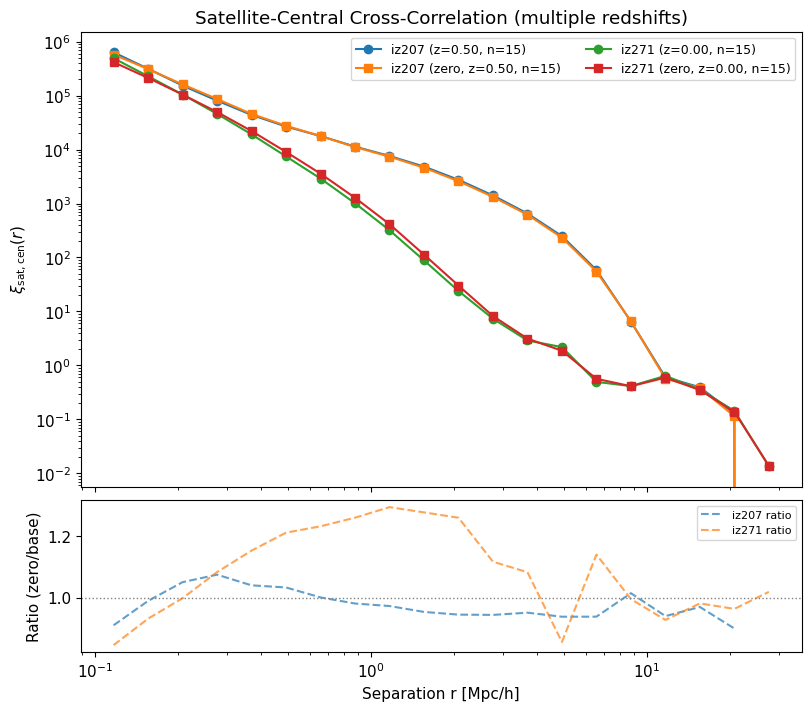

In [ ]:
snapshots = ['iz207', 'iz271']  # ['iz82', 'iz100', 'iz120', 'iz207', 'iz271']
ivols = list(range(0, 15))  # Independent samples to combine; adjust to available ivols.
r_ref = 0.5 * (DEFAULT_RBINS[:-1] + DEFAULT_RBINS[1:])

fig, (ax, ax_ratio) = plt.subplots(
    2,
    1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
    constrained_layout=True,
 )

for snapshot in snapshots:
    z_val = get_snapshot_redshift(snapshot)
    z_label = f"{z_val:.2f}" if z_val is not None else "n/a"

    xi_stack_base, xi_stack_zero = [], []
    n_used = 0
    for ivol in ivols:
        res_base = satellite_central_cross_correlation(
            base_dir / snapshot,
            ivol,
            rbins=DEFAULT_RBINS,
            nthreads=4,
            satellite_stellar_mass_min=satellite_stellar_mass_min,
            central_stellar_mass_min=central_stellar_mass_min,
            host_halo_mass_min=host_halo_mass_min,
        )
        res_zero = satellite_central_cross_correlation(
            zero_dir / snapshot,
            ivol,
            rbins=DEFAULT_RBINS,
            nthreads=4,
            satellite_stellar_mass_min=satellite_stellar_mass_min,
            central_stellar_mass_min=central_stellar_mass_min,
            host_halo_mass_min=host_halo_mass_min,
        )

        xi_vals_base = res_base['xi'].values
        xi_stack_base.append(xi_vals_base)

        xi_vals_zero = res_zero['xi'].values
        xi_stack_zero.append(xi_vals_zero)
        
        n_used += 1
            
    xi_stack_base = np.array(xi_stack_base)
    xi_mean_base = np.nanmean(xi_stack_base, axis=0)
    xi_std_base = np.nanstd(xi_stack_base, axis=0)

    xi_stack_zero = np.array(xi_stack_zero)
    xi_mean_zero = np.nanmean(xi_stack_zero, axis=0)
    xi_std_zero = np.nanstd(xi_stack_zero, axis=0)


    valid_base = np.isfinite(xi_mean_base) & (xi_mean_base > -1) & np.isfinite(r_ref)
    if not np.any(valid_base):
        print(f"Skipped {snapshot}: no finite xi after averaging base")
        continue

    valid_zero = np.isfinite(xi_mean_zero) & (xi_mean_zero > -1) & np.isfinite(r_ref)
    if not np.any(valid_zero):
        print(f"Skipped {snapshot}: no finite xi after averaging zero")
        continue

    ax.loglog(r_ref[valid_base], xi_mean_base[valid_base], 'o-', label=f"{snapshot} (z={z_label}, n={n_used})")
    ax.loglog(r_ref[valid_zero], xi_mean_zero[valid_zero], 's-', label=f"{snapshot} (zero, z={z_label}, n={n_used})")

    ratio_mask = valid_base & valid_zero & (xi_mean_base > 0)
    if np.any(ratio_mask):
        ratio = xi_mean_zero[ratio_mask] / xi_mean_base[ratio_mask]
        ax_ratio.semilogx(
            r_ref[ratio_mask],
            ratio,
            '--',
            label=f"{snapshot} ratio",
            alpha=0.7,
        )

ax.set_ylabel(r'$\xi_{\mathrm{sat,cen}}(r)$')
ax.set_title('Satellite-Central Cross-Correlation (multiple redshifts)')
ax.legend(ncol=2, fontsize=9, loc='upper right')

ax_ratio.set_xlabel('Separation r [Mpc/h]')
ax_ratio.set_ylabel('Ratio (zero/base)')
ax_ratio.axhline(1.0, color='0.5', lw=1, ls=':')
ax_ratio.legend(fontsize=8, loc='upper right')
plt.show()